In [1]:
!unzip -q /content/drive/MyDrive/Colab/acne_subtype_classification/AcneSCU.zip -d /content/dataset
!pip install mediapipe --quiet
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.7 MB/s eta 0:00:00


In [2]:
import os
import json
import cv2
import urllib.request
import numpy as np
import pandas as pd
import optuna
from tqdm import tqdm
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
# AcneSCU Dataset you must go to original Dataset for AcneSCU(originally in COCO JSON format)
WHOLE_IMG_DIR = '/content/dataset/AcneSCU/images'
COCO_JSON_PATH = '/content/dataset/AcneSCU/annotations/all_whole.json'
NEW_CROP_DIR = '/content/ACNE_SCU_cropped_image_folder_format_new'
CSV_OUTPUT_PATH = '/content/handcrafed_features.csv'
MP_TASK_PATH = 'face_landmarker.task'
PRETRAINED_WEIGHTS_PATH = '/content/drive/MyDrive/Colab/acne_subtype_classification/acne04_pretrained_weights.pth' # Switch to path you store the pre-trained weight of Acne04
MODELS_DIR = '/content/saved_cv_models'
os.makedirs(MODELS_DIR)

In [4]:
CLASSES = ['closed_comedo', 'open_comedo', 'papule', 'pustule', 'nodule']
IMG_SHAPE = (128, 128)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTER_SPLITS = 5
INNER_SPLITS = 3
OPTUNA_TRIALS = 20
CNN_EPOCHS = 5

In [5]:
class AcneFeatureDataset(Dataset):
    def __init__(self, image_paths, labels, tabular_features, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.tabular = tabular_features
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.image_paths[idx]), cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.tabular[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

class ChannelAttention_Large(nn.Module):
    def __init__(self, in_planes, ratio=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_p = self.avg_pool(x)
        avg_f1 = self.fc1(avg_p)
        avg_relu = self.relu(avg_f1)
        avg_f2 = self.fc2(avg_relu)

        max_p = self.max_pool(x)
        max_f1 = self.fc1(max_p)
        max_relu = self.relu(max_f1)
        max_f2 = self.fc2(max_relu)

        return self.sigmoid(avg_f2 + max_f2)


class SpatialAttention_Large(nn.Module):
    def __init__(self, kernel_size=11):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return nn.Sigmoid()(self.conv1(torch.cat([avg_out, max_out], dim=1)))

class CBAM_Large(nn.Module):
    def __init__(self, in_planes):
        super().__init__()
        self.ca = ChannelAttention_Large(in_planes)
        self.sa = SpatialAttention_Large()

    def forward(self, x):
        x = x * self.ca(x)
        return x * self.sa(x)

class AcneNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        self.cbam = CBAM_Large(in_planes=576)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(576, 256),
            nn.Hardswish(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = torch.flatten(self.pool(self.cbam(self.backbone.features(x))), 1)
        return self.classifier(features), features

In [6]:
def get_transforms():
    train_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(IMG_SHAPE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    eval_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(IMG_SHAPE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return train_transform, eval_transform

In [7]:
def extract_handcrafted_features():
    if os.path.exists(CSV_OUTPUT_PATH) and os.path.exists(NEW_CROP_DIR):
        return pd.read_csv(CSV_OUTPUT_PATH)

    os.makedirs(NEW_CROP_DIR, exist_ok=True)
    for cls in CLASSES:
        os.makedirs(os.path.join(NEW_CROP_DIR, cls), exist_ok=True)

    if not os.path.exists(MP_TASK_PATH):
        urllib.request.urlretrieve("https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task", MP_TASK_PATH)

    base_options = python.BaseOptions(model_asset_path=MP_TASK_PATH)
    detector = vision.FaceLandmarker.create_from_options(vision.FaceLandmarkerOptions(base_options=base_options, num_faces=1))

    with open(COCO_JSON_PATH, 'r') as f:
        coco = json.load(f)

    cat_id_to_name = {cat['id']: cat['name'].lower() for cat in coco['categories']}
    img_id_to_file = {img['id']: img['file_name'] for img in coco['images']}

    anns_by_img = {}
    for ann in coco['annotations']:
        anns_by_img.setdefault(ann['image_id'], []).append(ann)

    csv_data = []
    for img_id, img_name in tqdm(img_id_to_file.items(), disable=False):
        if img_id not in anns_by_img:
            continue

        img = cv2.imread(os.path.join(WHOLE_IMG_DIR, img_name))
        if img is None:
            continue

        h_img, w_img, _ = img.shape
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        results = detector.detect(mp_image)

        if results.face_landmarks:
            lms = results.face_landmarks[0]
            def get_pt(idx): return np.array([lms[idx].x * w_img, lms[idx].y * h_img])
            ipd = np.linalg.norm(get_pt(468) - get_pt(473))
            nw = np.linalg.norm(get_pt(129) - get_pt(358))
            mw = np.linalg.norm(get_pt(61) - get_pt(291))
            all_x, all_y = [lm.x * w_img for lm in lms], [lm.y * h_img for lm in lms]
            face_area = (max(all_x) - min(all_x)) * (max(all_y) - min(all_y))
        else:
            ipd, nw, mw, face_area = w_img * 0.35, w_img * 0.20, w_img * 0.30, w_img * h_img * 0.50

        for ann in anns_by_img[img_id]:
            cat_name = cat_id_to_name.get(ann['category_id'], 'unknown')
            if cat_name not in CLASSES:
                continue

            x, y, w, h = [int(v) for v in ann['bbox']]
            x1, y1, x2, y2 = max(0, x), max(0, y), min(w_img, x + w), min(h_img, y + h)
            if x2 <= x1 or y2 <= y1:
                continue

            D_L, lesion_area = max(w, h), w * h
            f1_ipd = D_L/ipd if ipd > 0 else 0
            f2_nose = D_L/nw if nw > 0 else 0
            f3_mouth = D_L/mw if mw > 0 else 0
            f4_area = lesion_area/face_area if face_area > 0 else 0

            crop_img = img[y1:y2, x1:x2]
            if crop_img.size == 0:
                continue

            img_hsv_crop = cv2.cvtColor(crop_img, cv2.COLOR_BGR2HSV)
            img_rgb_crop = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)

            r, g, _ = cv2.split(img_rgb_crop)
            redness_idx = max(0, np.mean(r.astype(np.float32) - g.astype(np.float32))) / 255.0

            v_channel = img_hsv_crop[:,:,2].astype(np.float32) / 255.0
            brightness_idx = np.mean(v_channel)
            k = max(1, int(v_channel.size * 0.2))
            darkness_idx = 1.0 - np.mean(np.partition(v_channel.flatten(), k)[:k])

            s_channel = img_hsv_crop[:,:,1].astype(np.float32) / 255.0
            pustule_center_score = np.sum((v_channel > 0.75) & (s_channel < 0.40)) / lesion_area

            crop_filename = f"{img_id}_{ann['id']}.jpg"
            crop_path = os.path.join(NEW_CROP_DIR, cat_name, crop_filename)
            if not os.path.exists(crop_path):
                cv2.imwrite(crop_path, crop_img)

            csv_data.append({
                'filename': crop_filename,
                'class_name': cat_name,
                'Geo_Combined_Ratio': f1_ipd * f2_nose * f3_mouth,
                'Face_Area_Ratio': f4_area,
                'Nodule_Score': f4_area * redness_idx,
                'Papule_Score': redness_idx / (1.0 + (f4_area * 10000)),
                'Pustule_Score': (redness_idx * brightness_idx) * (1.0 + (pustule_center_score * 5.0)),
                'Closed_Comedo_Score': (1.0 - redness_idx) * brightness_idx,
                'Open_Comedo_Score': (1.0 - redness_idx) * darkness_idx
            })

    df = pd.DataFrame(csv_data)
    df.to_csv(CSV_OUTPUT_PATH, index=False)
    return df

In [8]:
def build_data_arrays(df_features):
    feature_cols = ['Geo_Combined_Ratio', 'Face_Area_Ratio', 'Nodule_Score', 'Papule_Score', 'Pustule_Score', 'Closed_Comedo_Score', 'Open_Comedo_Score']
    feature_dict = df_features.set_index('filename')[feature_cols].T.to_dict('list')

    img_paths, y, all_tabular_feats = [], [], []
    for class_idx, class_name in enumerate(CLASSES):
        class_dir = os.path.join(NEW_CROP_DIR, class_name)
        if not os.path.isdir(class_dir):
            continue
        for img_name in [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]:
            img_paths.append(os.path.join(class_dir, img_name))
            y.append(class_idx)
            all_tabular_feats.append(feature_dict.get(img_name, [0.0]*7))

    return np.array(img_paths), np.array(y), np.array(all_tabular_feats)

In [9]:
def initialize_cnn():
    model = AcneNet(num_classes=5).to(DEVICE)
    if os.path.exists(PRETRAINED_WEIGHTS_PATH):
        pretrained_dict = {k: v for k, v in torch.load(PRETRAINED_WEIGHTS_PATH, map_location=DEVICE).items() if not k.startswith('classifier.3')}
        model.load_state_dict(pretrained_dict, strict=False)
    for param in model.backbone.features[:9].parameters():
        param.requires_grad = False
    return model

In [10]:
def train_cnn(model, train_loader, criterion, optimizer, epochs=CNN_EPOCHS):
    model.train()
    for _ in range(epochs):
        for imgs, _, labels in train_loader:
            optimizer.zero_grad()
            outputs, _ = model(imgs.to(DEVICE))
            loss = criterion(outputs, labels.to(DEVICE))
            loss.backward()
            optimizer.step()
    return model

In [11]:
def extract_cnn_features(model, loader):
    model.eval()
    feats_list = []
    with torch.no_grad():
        for imgs, _, _ in loader:
            _, features = model(imgs.to(DEVICE))
            feats_list.append(features.cpu().numpy())
    return np.vstack(feats_list)

In [12]:
def tune_hyperparameters(X_cnn_train, X_tab_train, y_train):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'eval_metric': 'mlogloss',
            'n_jobs': -1,
            'random_state': 42
        }

        inner_cv = StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=42)
        scores = []

        for in_tr_idx, in_val_idx in inner_cv.split(X_cnn_train, y_train):
            X_cnn_in_tr, X_cnn_in_val = X_cnn_train[in_tr_idx], X_cnn_train[in_val_idx]
            X_tab_in_tr, X_tab_in_val = X_tab_train[in_tr_idx], X_tab_train[in_val_idx]
            y_in_tr, y_in_val = y_train[in_tr_idx], y_train[in_val_idx]

            scaler = StandardScaler()
            X_cnn_in_tr_sc = scaler.fit_transform(X_cnn_in_tr)
            X_cnn_in_val_sc = scaler.transform(X_cnn_in_val)

            pca = PCA(n_components=128, random_state=42)
            X_cnn_in_tr_pca = pca.fit_transform(X_cnn_in_tr_sc)
            X_cnn_in_val_pca = pca.transform(X_cnn_in_val_sc)

            pt = PowerTransformer(standardize=True)
            X_tab_in_tr_tf = pt.fit_transform(X_tab_in_tr)
            X_tab_in_val_tf = pt.transform(X_tab_in_val)

            X_in_tr_fused = np.hstack([X_cnn_in_tr_pca, X_tab_in_tr_tf])
            X_in_val_fused = np.hstack([X_cnn_in_val_pca, X_tab_in_val_tf])

            X_in_tr_sm, y_in_tr_sm = SMOTE(random_state=42).fit_resample(X_in_tr_fused, y_in_tr)
            weights = np.array([{0:1.0, 1:1.0, 2:1.0, 3:2.0, 4:1.5}[c] for c in y_in_tr_sm])

            xgb = XGBClassifier(**params).fit(X_in_tr_sm, y_in_tr_sm, sample_weight=weights)
            scores.append(f1_score(y_in_val, xgb.predict(X_in_val_fused), average='macro'))

        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
    return study.best_params

In [13]:
def plot_feature_importance(xgb_model, pca_operator, csv_name='all_feature_importances.csv'):
    handcrafted_names = ['Geo_Combined_Ratio', 'Face_Area_Ratio', 'Nodule_Score', 'Papule_Score', 'Pustule_Score', 'Closed_Comedo_Score', 'Open_Comedo_Score']
    pca_names = [f'CNN_PCA_{i+1}' for i in range(pca_operator.n_components_)]
    all_feature_names = pca_names + handcrafted_names

    feat_imp_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': xgb_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    feat_imp_df.to_csv(csv_name, index=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(20), palette='viridis')
    plt.title('Top 20 Hybrid Feature Importances')
    plt.xlabel('F-Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

In [14]:
def execute_pipeline(img_paths, y, all_tabular_feats):
    outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=42)
    y_pred_cv = np.zeros_like(y)

    cnn_class_weights = torch.tensor([1.0, 1.0, 1.0, 2.0, 1.5], dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cnn_class_weights)
    train_transform, eval_transform = get_transforms()

    final_xgb = None
    final_pca = None
    outer_loop = tqdm(outer_cv.split(img_paths, y), total=OUTER_SPLITS, desc="Overall Nested CV")
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(img_paths, y)):
        outer_loop.set_description(f"Fold {fold+1}/{OUTER_SPLITS}")
        train_paths, test_paths = img_paths[train_idx], img_paths[test_idx]
        train_y, test_y = y[train_idx], y[test_idx]
        train_tab, test_tab = all_tabular_feats[train_idx], all_tabular_feats[test_idx]

        train_loader = DataLoader(AcneFeatureDataset(train_paths, train_y, train_tab, train_transform), batch_size=64, shuffle=True)
        train_ext_loader = DataLoader(AcneFeatureDataset(train_paths, train_y, train_tab, eval_transform), batch_size=64, shuffle=False)
        test_ext_loader = DataLoader(AcneFeatureDataset(test_paths, test_y, test_tab, eval_transform), batch_size=64, shuffle=False)

        model = initialize_cnn()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

        model = train_cnn(model, train_loader, criterion, optimizer, CNN_EPOCHS)

        X_cnn_tr_out = extract_cnn_features(model, train_ext_loader)
        X_cnn_te_out = extract_cnn_features(model, test_ext_loader)

        best_params = tune_hyperparameters(X_cnn_tr_out, train_tab, train_y)
        best_params.update({'eval_metric': 'mlogloss', 'n_jobs': -1, 'random_state': 42})

        scaler = StandardScaler()
        X_cnn_tr_sc = scaler.fit_transform(X_cnn_tr_out)
        X_cnn_te_sc = scaler.transform(X_cnn_te_out)

        pca = PCA(n_components=128, random_state=42)
        X_cnn_tr_pca = pca.fit_transform(X_cnn_tr_sc)
        X_cnn_te_pca = pca.transform(X_cnn_te_sc)

        pt = PowerTransformer(standardize=True)
        X_tab_tr_tf = pt.fit_transform(train_tab)
        X_tab_te_tf = pt.transform(test_tab)

        X_tr_fused = np.hstack([X_cnn_tr_pca, X_tab_tr_tf])
        X_te_fused = np.hstack([X_cnn_te_pca, X_tab_te_tf])

        smote = SMOTE(random_state=42)
        X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_fused, train_y)
        weights = np.array([{0:1.0, 1:1.0, 2:1.0, 3:2.0, 4:1.5}[c] for c in y_tr_sm])

        xgb = XGBClassifier(**best_params).fit(X_tr_sm, y_tr_sm, sample_weight=weights)
        y_pred_cv[test_idx] = xgb.predict(X_te_fused)

        xgb.save_model(os.path.join(MODELS_DIR, f"xgb_fold_{fold}.json"))
        joblib.dump(pca, os.path.join(MODELS_DIR, f"pca_fold_{fold}.pkl"))
        joblib.dump(scaler, os.path.join(MODELS_DIR, f"scaler_fold_{fold}.pkl"))
        joblib.dump(pt, os.path.join(MODELS_DIR, f"powertransformer_fold_{fold}.pkl"))

        if fold == OUTER_SPLITS - 1:
            final_xgb = xgb
            final_pca = pca

    print(classification_report(y, y_pred_cv, target_names=CLASSES))

    if final_xgb and final_pca:
        plot_feature_importance(final_xgb, final_pca)


Outer CV Folds:   0%|          | 0/5 [00:00<?, ?it/s]


--- Starting Outer Fold 1/5 ---



Fine-tuning CNN: 100%|██████████| 5/5 [01:32<00:00, 18.56s/it]
                                                              

Extracting CNN Features...



Optuna Trials: 100%|██████████| 20/20 [23:17<00:00, 86.27s/it]
                                                              

...


Optuna Trials: 100%|██████████| 20/20 [21:30<00:00, 47.24s/it]
                                                              

Training Final XGBoost for Fold...


Outer CV Folds: 100%|██████████| 5/5 [1:54:41<00:00, 1376.31s/it]

Saving models for Fold 5...

FINAL TRIAL REPORT (Nested CV + Optuna)
               precision    recall  f1-score   support

closed_comedo       0.85      0.87      0.86      5877
  open_comedo       0.93      0.92      0.92      3297
       papule       0.85      0.81      0.83      5550
      pustule       0.62      0.68      0.65      1268
       nodule       0.68      0.83      0.75       209

     accuracy                           0.84     16201
    macro avg       0.79      0.82      0.80     16201
 weighted avg       0.85      0.84      0.85     16201


Generating Feature Importance Plot for the final fold...

✅ Saved all 135 feature importances to: all_feature_importances.csv



/tmp/ipykernel_923/2406201349.py:236: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(20), palette='viridis')


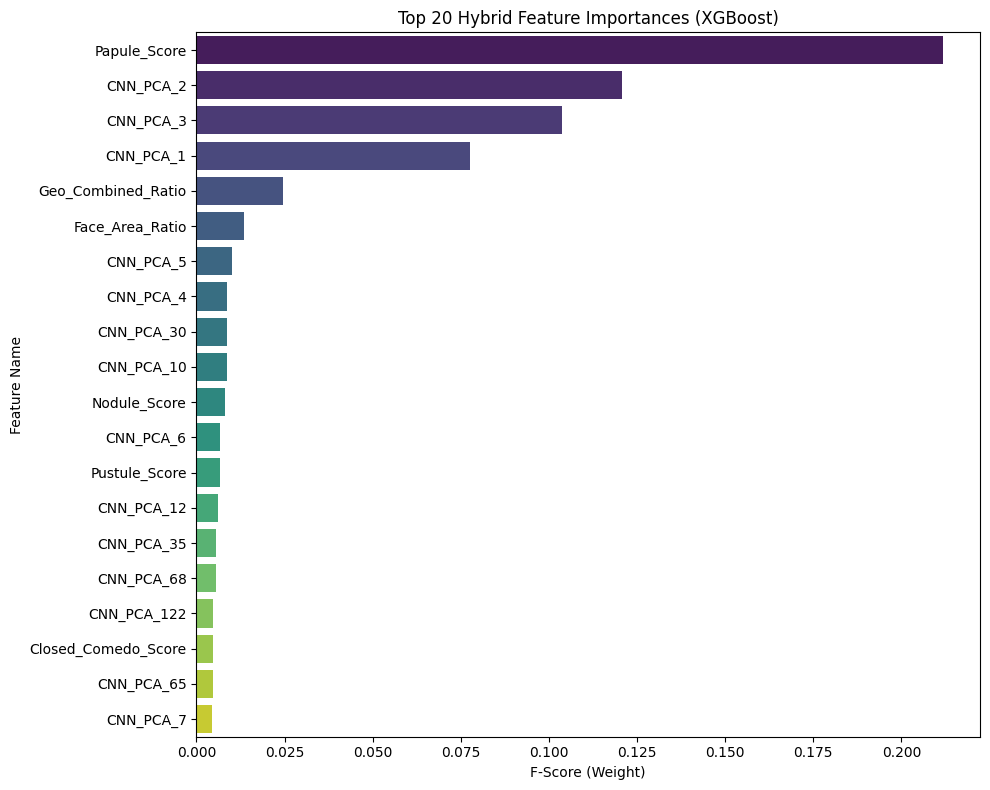


--- Handcrafted Feature Importance ---
            Feature  Importance
       Papule_Score    0.211700
 Geo_Combined_Ratio    0.024546
    Face_Area_Ratio    0.013528
       Nodule_Score    0.008219
      Pustule_Score    0.006646
Closed_Comedo_Score    0.004750
  Open_Comedo_Score    0.003746


In [ ]:
df = extract_handcrafted_features()
paths, labels, tabular = build_data_arrays(df)
execute_pipeline(paths, labels, tabular)